## Algoritmos de Agrupamiento Jerárquico

Los algoritmos de agrupamiento jerárquico son técnicas de análisis de datos que se utilizan para agrupar un conjunto de objetos en una estructura jerárquica de clústeres. Esta estructura se puede visualizar como un **dendrograma**, que es un diagrama en forma de árbol.

Estos algoritmos permiten crear una organización de los datos en niveles de agrupación, desde clústeres amplios (que incluyen muchos datos) hasta clústeres más específicos y detallados. Existen dos enfoques principales en el agrupamiento jerárquico:
1. **Agrupamiento jerárquico aglomerativo**
2. **Agrupamiento jerárquico divisivo**


## Agrupamiento Jerárquico Aglomerativo

Este es el enfoque más común en el agrupamiento jerárquico. El proceso comienza con cada punto de datos considerado como un clúster separado. Luego, en cada paso del algoritmo, se identifican los dos clústeres más similares (es decir, aquellos que están más cerca entre sí según una medida de distancia o similitud). Estos dos clústeres se fusionan para formar un nuevo clúster.

El proceso se repite hasta que todos los puntos de datos estén agrupados en un único clúster o se haya alcanzado un número deseado de clústeres.

Este proceso es iterativo y puede visualizarse de manera clara a través de un dendrograma.


### Ejemplo visual del agrupamiento jerárquico aglomerativo

En la siguiente figura se muestra un ejemplo de 12 puntos y el dendrograma resultante de un proceso de agrupamiento jerárquico aglomerativo:

<table>
  <tr>
    <td><img src="https://drive.google.com/uc?export=view&id=1fBT3TvpzC3_sxPvDqpI162H4LgAjyq-q" width="400"></td>
    <td><img src="https://drive.google.com/uc?export=view&id=1d-3os2YYQ4AvyU4dIJ2iQerqgIrlA8HL" width="400"></td>
  </tr>
  <tr>
    <td>Ejemplo de 12 puntos</td>
    <td>Dendrograma resultante</td>
  </tr>
</table>

Al leer el dendrograma de abajo hacia arriba, observamos que inicialmente cada punto es un clúster individual. Luego, se fusionan puntos como los 1 y 3, y así sucesivamente hasta formar un único clúster.



## Consideraciones sobre el coste computacional

El agrupamiento jerárquico aglomerativo puede ser computacionalmente costoso para conjuntos de datos grandes debido a la necesidad de calcular y actualizar continuamente las distancias entre todos los clústeres. A pesar de este costo, su capacidad para representar visualmente la estructura de los datos lo convierte en una herramienta valiosa en el análisis de datos.



## Agrupamiento Jerárquico Divisivo

Este enfoque, menos común, comienza con todos los objetos en un solo clúster. Luego, el algoritmo divide iterativamente este clúster en subclústeres más pequeños hasta que cada objeto está en un clúster individual o se alcanza un criterio de división predefinido.

A diferencia del enfoque aglomerativo, el agrupamiento divisivo permite una descomposición flexible de los clústeres, adaptándose a la estructura de los datos.

### Manejo de la heterogeneidad en el agrupamiento divisivo

A medida que el clúster original se divide en subclústeres, los resultados pueden mostrar una mayor variabilidad en los subgrupos. Esto permite descubrir estructuras más complejas en los datos que podrían no ser evidentes en un agrupamiento aglomerativo.

Este enfoque puede ser útil cuando los datos son muy heterogéneos y requieren una división más flexible y dinámica.

#Agrupamiento jerárquico en la NFL

Ahora vamos a repetir el ejercicio asociado con la formación de grupos de jugadores de acuerdo a su peso y estatura, pero esta vez aplicaremos el agrupamiento jerárquico.

Comenzamos importando algunas de las bibliotecas que emplearemos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

A continuación:
* Activamos la unidad $\textit{Drive}$.
* Empleamos la biblioteca Pandas para leer y guardar la información del archivo $NFL\_Filtrado.csv$ en un $Dataframe$, $\textit{df}$.

In [ ]:
# Enlace del archivo CSV en Google Drive
ruta_csv = "/content/drive/MyDrive/Inteligencia Artificial Aplicada/Clustering/NFL_Filtrado.csv"

# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(ruta_csv)

#Imprimir la información del dataframe
print(df.head())

   Height (inches)  Weight (lbs) Position
0               77           305       DE
1               72           210       DB
2               74           190       CB
3               74           208       CB
4               72           212       FS


#Normalización
Ahora es necesario preparar los datos antes de aplicar cualquier algoritmo de clustering.

Importamos la clase $\textit{MinMaxScaler}$ desde el módulo $\textit{preprocessing}$ de la biblioteca $\texttt{scikit-learn}$, para normalizar los datos.

La normalización es crucial, ya que los algoritmos de clustering son sensibles a la escala de las variables.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Extraer las columnas de altura y peso
X = df[['Height (inches)', 'Weight (lbs)']]

# Normalizar los datos
scaler = MinMaxScaler()
X_normalizado = scaler.fit_transform(X)
print(X_normalizado)

[[0.71428571 0.71359223]
 [0.35714286 0.25242718]
 [0.5        0.15533981]
 ...
 [0.42857143 0.22815534]
 [0.42857143 0.14563107]
 [0.85714286 0.62621359]]


Listo, estamos en condiciones para aplicar agrupamiento jerárquico, para lo cual importamos la clase $\textit{AgglomerativeClustering}$ desde el módulo $\textit{cluster}$ de la biblioteca $\texttt{scikit-learn}$.

De acuerdo a lo mencionado para este ejemplo vamos a considerar dos clústeres, $k=2$.


In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
# Definir el número de clústeres
jerarquico = AgglomerativeClustering(n_clusters=2)

# Ajustar el modelo a los datos
jerarquico.fit(X_normalizado)

# Obtener las etiquetas de los clústeres
df['Agrupamiento_jerarquico'] = jerarquico.labels_
df.head()

,Height (inches),Weight (lbs),Position,Agrupamiento_jerarquico
0,77,305,DE,0
1,72,210,DB,1
2,74,190,CB,1
3,74,208,CB,1
4,72,212,FS,1


Para visualizar los resultados del clustering, podemos utilizar un diagrama de dispersión coloreado según las etiquetas de los clústeres.

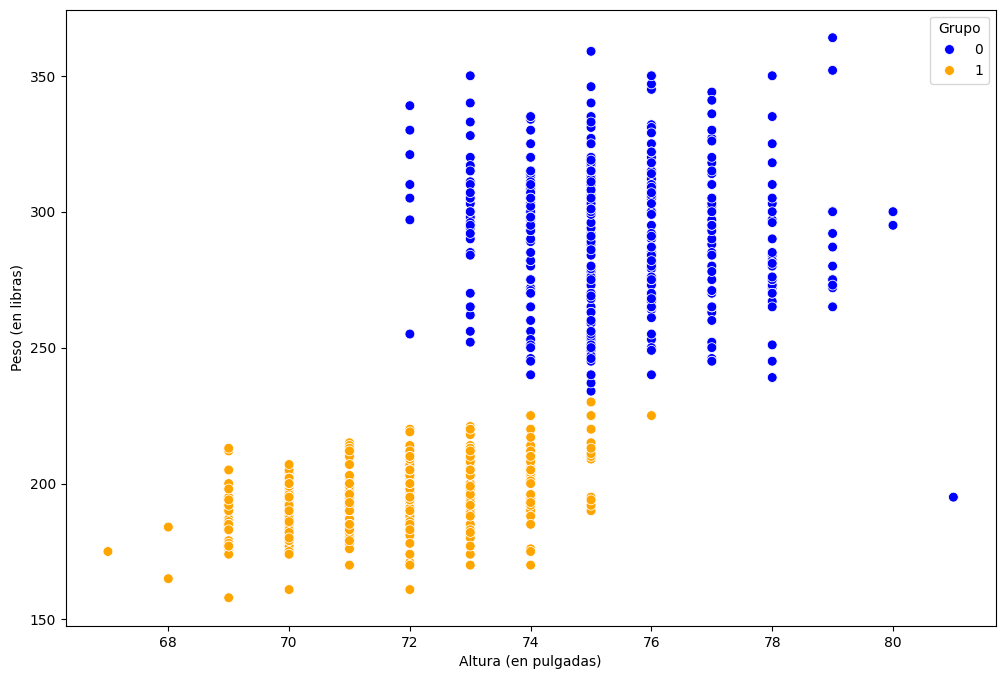

In [ ]:
# Crear el diagrama de dispersión
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Height (inches)', y='Weight (lbs)', hue='Agrupamiento_jerarquico', palette={0: 'blue', 1: 'orange'}, s=50, edgecolor='w')

# Configurar el título y las etiquetas
plt.xlabel('Altura (en pulgadas)')
plt.ylabel('Peso (en libras)')
plt.legend(title='Grupo', loc='upper right')

# Mostrar el gráfico
plt.show()

# Índice silueta
Calculemos el índice silueta para los clústeres formados.

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
# Calcular el Índice de Silueta
score = silhouette_score(X_normalizado, jerarquico.labels_)
print(f"Índice de Silueta: {score}")

Índice de Silueta: 0.6583289260622431
